# Calibración: cuando el modelo dice «90%», ¿es un 90%?

**Facsímil 7 · Evaluar, calibrar e interpretar** — capítulo 5 (calibración e incertidumbre: de *scores* a
decisiones).

Un modelo puede acertar mucho y, a la vez, **mentir con sus porcentajes**. Si vas a decidir con un
umbral («bloquea si la probabilidad de fraude supera 0,8»), más te vale que ese 0,8 sea de verdad un
80%. Un modelo **descalibrado** toma decisiones malas con total aplomo. En este cuaderno compruebas si
las probabilidades que da un modelo significan lo que dicen, lo mides con un *reliability diagram* y el
**ECE**, y lo corriges con *temperature scaling*. La calibración es lo que convierte un *score* en una
probabilidad de la que fiarte.

### Qué vas a aprender
- Que **acertar** y estar **calibrado** son cosas distintas.
- A leer un **reliability diagram** (lo prometido frente a lo cumplido) y a resumir el desajuste en un
  número, el **ECE**.
- A **recalibrar** con *temperature scaling* sin cambiar ni una predicción.
- Por qué los modelos «muy seguros de sí mismos» suelen estar peor calibrados.

### Cuánto cuesta
Unos 12 minutos. CPU, sin claves.


> **Inteligencia artificial para gente curiosa** · facsímil interactivo
> 
> Web del facsímil: https://www.iaparagentecuriosa.686f6c61.dev/ · Autor: @686f6c61 · Fecha: 2026-06-26 · Versión 1.0
> 
> Este cuaderno acompaña al facsímil: ejecútalo de arriba abajo, lee cada celda de texto
> antes de correr la de código y detente en las salidas. La gracia no es que «salga», sino
> entender *por qué* sale.

In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
np.random.seed(0)

X, y = make_classification(n_samples=4000, n_informative=6, n_redundant=2, random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.4, random_state=0)
modelo = RandomForestClassifier(n_estimators=60, max_depth=6, random_state=0).fit(X_tr, y_tr)
p = modelo.predict_proba(X_te)[:, 1]
print("Modelo entrenado. Acierto:", round((modelo.predict(X_te) == y_te).mean(), 3))
print("Pero, ¿son fiables sus probabilidades? Esa es OTRA pregunta, y la mas importante para decidir.")


Modelo entrenado. Acierto: 0.876
Pero, ¿son fiables sus probabilidades? Esa es OTRA pregunta, y la mas importante para decidir.


## 1. Acertar no es estar calibrado

Imagina dos médicos que aciertan el mismo número de diagnósticos. El primero, cuando dice «90% de
probabilidad», acierta 9 de cada 10 veces que lo dice. El segundo dice «90%» pero solo acierta 6 de cada
10: sus porcentajes son adornos. Ambos «aciertan» parecido, pero solo del primero puedes fiarte para
**decidir con un umbral**. Eso es la calibración: que la probabilidad declarada coincida con la
frecuencia real de aciertos. Un modelo puede tener buen acierto y estar mal calibrado.


## 2. El reliability diagram: prometido frente a cumplido

Agrupamos las predicciones por su probabilidad (las que rondan 0,1, las de 0,2...) y, en cada grupo,
miramos qué fracción era de verdad positiva. Si el modelo está calibrado, los puntos caen sobre la
diagonal: «cuando digo 0,7, acierto el 70%». Cuanto más se alejen, peor. El **ECE** (*expected
calibration error*) resume esa distancia media en un solo número, ponderando por cuántos casos hay en
cada grupo.


ECE (error de calibracion) del modelo: 0.092  (0 = perfecto)


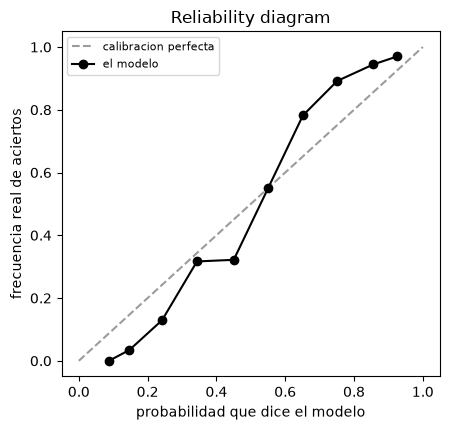

In [2]:
def reliability(p, y, bins=10):
    bordes = np.linspace(0, 1, bins+1)
    xs, ys, pesos = [], [], []
    for i in range(bins):
        m = (p >= bordes[i]) & (p < bordes[i+1])
        if m.sum() > 0:
            xs.append(p[m].mean()); ys.append(y[m].mean()); pesos.append(m.sum())
    return np.array(xs), np.array(ys), np.array(pesos)

def ece(p, y, bins=10):
    xs, ys, pesos = reliability(p, y, bins)
    return np.sum(pesos * np.abs(xs - ys)) / pesos.sum()

xs, ys, _ = reliability(p, y_te)
print(f"ECE (error de calibracion) del modelo: {ece(p, y_te):.3f}  (0 = perfecto)")
plt.figure(figsize=(4.6, 4.4))
plt.plot([0,1],[0,1], "--", color="#9c9c9c", label="calibracion perfecta")
plt.plot(xs, ys, "-o", color="black", label="el modelo")
plt.xlabel("probabilidad que dice el modelo"); plt.ylabel("frecuencia real de aciertos")
plt.title("Reliability diagram"); plt.legend(fontsize=8); plt.tight_layout(); plt.show()


**Lee la curva.** Donde la línea negra queda por debajo de la diagonal gris, el modelo es
**optimista** (promete más acierto del que cumple); por encima, es **tímido**. El ECE pone número a ese
desajuste. Un ECE alto significa que sus porcentajes no se pueden tomar al pie de la letra para decidir.


## 3. Corregirlo: temperature scaling

Una técnica simple y muy usada: dividir los *logits* por una **temperatura** T que se ajusta para que
las probabilidades encajen con la realidad (es la misma temperatura del cuaderno de *sampling* del
facsímil 3, usada ahora para calibrar). No cambia **qué clase predice** el modelo (ni su acierto), solo
**recalibra la confianza**. Buscamos la T que minimiza el ECE.


In [3]:
eps = 1e-6
logit = np.log(np.clip(p, eps, 1-eps) / (1 - np.clip(p, eps, 1-eps)))
def aplica_T(T): return 1 / (1 + np.exp(-logit / T))

Ts = np.linspace(0.5, 3.0, 26)
eces = [ece(aplica_T(T), y_te) for T in Ts]
mejor_T = Ts[int(np.argmin(eces))]
p_cal = aplica_T(mejor_T)
print(f"ECE antes:   {ece(p, y_te):.3f}")
print(f"Mejor T:     {mejor_T:.2f}")
print(f"ECE despues: {ece(p_cal, y_te):.3f}   (mas cerca de 0 = mas fiable)")
print(f"Acierto antes y despues: {(p>0.5).mean():.3f} / {(p_cal>0.5).mean():.3f} ... la prediccion no cambia.")


ECE antes:   0.092
Mejor T:     0.60
ECE despues: 0.025   (mas cerca de 0 = mas fiable)
Acierto antes y despues: 0.488 / 0.488 ... la prediccion no cambia.


## 4. Experimento: los modelos «muy seguros» se calibran peor

Una regularidad conocida: cuanto más complejo y «seguro de sí mismo» es un modelo, peor suele estar
calibrado, porque tiende a dar probabilidades extremas (0,99 / 0,01) más de lo que la realidad
justifica. Se ve nítido con un **árbol de decisión individual**: poco profundo, sus hojas agrupan muchos
casos y dan probabilidades suaves; muy profundo, sus hojas son «puras» (todo 0 o todo 1), así que cuando
se equivoca en datos nuevos lo hace con un 100% de (falsa) confianza. Medimos su ECE según la
profundidad.


In [4]:
from sklearn.tree import DecisionTreeClassifier
print("profundidad |  acierto | ECE (calibracion, menor = mejor)")
for prof in [2, 4, 8, None]:
    m = DecisionTreeClassifier(max_depth=prof, random_state=0).fit(X_tr, y_tr)
    pp = m.predict_proba(X_te)[:, 1]
    etiqueta = "sin lim." if prof is None else str(prof)
    print(f"   {etiqueta:>8} |  {(m.predict(X_te)==y_te).mean():.3f}  |  {ece(pp, y_te):.3f}")
print("\nEl arbol profundo da probabilidades extremas (hojas puras): peor calibrado, mas sobreconfiado.")


profundidad |  acierto | ECE (calibracion, menor = mejor)
          2 |  0.829  |  0.019
          4 |  0.843  |  0.025
          8 |  0.864  |  0.080
   sin lim. |  0.853  |  0.135

El arbol profundo da probabilidades extremas (hojas puras): peor calibrado, mas sobreconfiado.


## 5. Pruébalo tú

1. **Mira un caso concreto:** busca predicciones de «0,9» y comprueba en su grupo si de verdad aciertan
   el 90%. La calibración se siente cuando es *tu* decisión la que depende de ese número.
2. **Decide con umbral:** bloquea si la probabilidad supera 0,8, antes y después de calibrar. ¿Cambian
   las decisiones? Por eso calibrar no es un lujo académico.
3. **Otra calibración:** prueba *Platt scaling* (una regresión logística sobre las probabilidades) y
   compara su ECE con el de *temperature scaling*.
4. **Pocos vs muchos bins** en el reliability diagram: ¿cambia mucho el ECE? El número de grupos influye
   en la medida.


## 6. Errores comunes

- **Confundir acierto y calibración.** Un modelo puede acertar mucho y mentir con sus porcentajes.
- **Tomar las probabilidades al pie de la letra sin comprobarlas.** Si vas a decidir con un umbral,
  primero mide el ECE.
- **Calibrar con los mismos datos de entrenamiento.** La calibración se ajusta y se mide en datos
  apartados, no en los de entrenar.
- **Creer que recalibrar cambia las predicciones.** *Temperature scaling* no toca qué clase predice el
  modelo, solo su confianza.


## 7. Qué te llevas

- **Acierto y calibración son cosas distintas:** un modelo puede acertar mucho y aun así no ser fiable en
  sus probabilidades.
- El **reliability diagram** y el **ECE** miden si «0,8» significa de verdad 80%; el *temperature
  scaling* lo corrige sin tocar las predicciones.
- Los modelos **más seguros de sí mismos** tienden a estar peor calibrados: dan probabilidades
  exageradas.
- Si decides con un umbral sobre la probabilidad, **necesitas** que esa probabilidad sea honesta.

**Para seguir:** el siguiente cuaderno usa estas probabilidades para elegir el umbral que minimiza el
coste real de equivocarse; el capítulo 6 trata la interpretabilidad.


---

### Ficha del cuaderno

- **Obra:** *Inteligencia artificial para gente curiosa* (facsímil interactivo).
- **Web:** https://www.iaparagentecuriosa.686f6c61.dev/
- **Autor:** @686f6c61
- **Fecha:** 2026-06-26
- **Versión:** 1.0

*Material pedagógico. Las salidas que ves son reales: se generan al ejecutar el código, no están escritas a mano. Si cambias algo, cambiarán: esa es la idea.*